In [ ]:
#!pip install pandas matplotlib seaborn scikit-learn pycaret shap  --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18

In [1]:
   import pandas as pd
   import numpy as np
   import matplotlib.pyplot as plt
   import seaborn as sns
   from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
   from google.colab import drive
   drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Dataset2/heart DIDDY.csv')

In [4]:
display(df.head())
print(df.shape)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


(918, 12)


In [5]:
print(df.describe())

              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198.799564    0.233115  136.809368   
std      9.432617   18.514154   109.384145    0.423046   25.460334   
min     28.000000    0.000000     0.000000    0.000000   60.000000   
25%     47.000000  120.000000   173.250000    0.000000  120.000000   
50%     54.000000  130.000000   223.000000    0.000000  138.000000   
75%     60.000000  140.000000   267.000000    0.000000  156.000000   
max     77.000000  200.000000   603.000000    1.000000  202.000000   

          Oldpeak  HeartDisease  
count  918.000000    918.000000  
mean     0.887364      0.553377  
std      1.066570      0.497414  
min     -2.600000      0.000000  
25%      0.000000      0.000000  
50%      0.600000      1.000000  
75%      1.500000      1.000000  
max      6.200000      1.000000  


df pre-processing


In [ ]:
missing_values = df.isnull().sum()
print(missing_values)

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


Outlier detection



/tmp/ipython-input-1015512105.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[c] for c in cols], labels=cols)


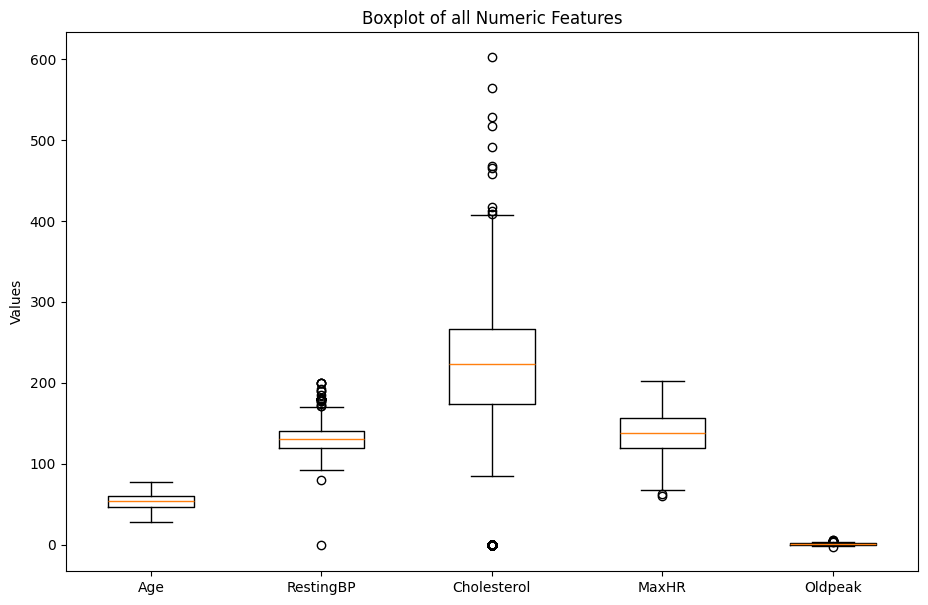

In [ ]:
#Oulier detection for every numeric feature
cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

plt.figure(figsize=(11,7))
plt.boxplot([df[c] for c in cols], labels=cols)
plt.title("Boxplot of all Numeric Features")
plt.ylabel("Values")
plt.show()

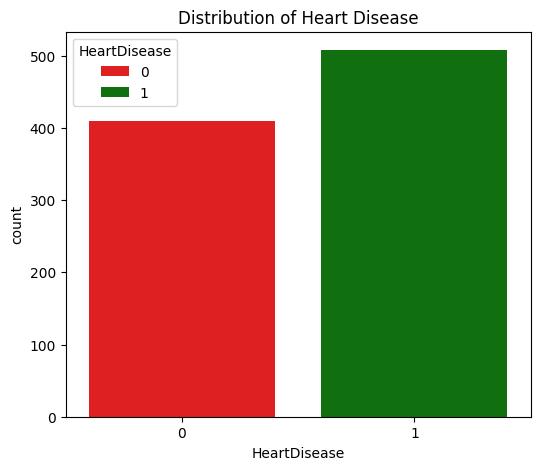

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(x='HeartDisease', hue='HeartDisease', data=df, palette={0: 'red', 1: 'green'})
plt.title('Distribution of Heart Disease')
plt.show()

train test


In [ ]:
from sklearn.model_selection import train_test_split


# Split into train/testing set
X_train, X_test, y_train, y_test = train_test_split(
    pd.get_dummies(df.drop(columns='HeartDisease'), drop_first=True),
    df['HeartDisease'],
    test_size=0.2,
    random_state=69, stratify=df['HeartDisease'] # To preserve class balance, we add -> stratify=df['HeartDisease']
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (734, 15)
Testing set shape: (184, 15)


Part 2- AutoML algorithms


In [ ]:
from pycaret.classification import *

In [ ]:
#PYCARET for df
#data gets the training set, `test_data` gets the hold-out set.


pycaret_df = pd.concat([X_train, y_train], axis=1) #doing this because we manually split data into train and test
pycaret_s = setup(data=pycaret_df, target='HeartDisease', session_id=69, verbose=False)


In [ ]:
best = compare_models()
tuned = tune_model(best)
final = finalize_model(tuned)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.8654,0.9241,0.8905,0.8712,0.8796,0.7269,0.7297,0.0520
ridge,Ridge Classifier,0.8634,0.9235,0.8905,0.8688,0.8782,0.7227,0.7259,0.0340
rf,Random Forest Classifier,0.8596,0.9101,0.9121,0.8491,0.8779,0.7131,0.7199,0.2120
lr,Logistic Regression,0.8575,0.9213,0.8869,0.8628,0.8728,0.7107,0.7157,1.0110
nb,Naive Bayes,0.8557,0.9162,0.8909,0.8569,0.8720,0.7066,0.7109,0.0340
gbc,Gradient Boosting Classifier,0.8461,0.9027,0.8771,0.8520,0.8628,0.6876,0.6914,0.2830
et,Extra Trees Classifier,0.8440,0.9054,0.8701,0.8561,0.8607,0.6833,0.6887,0.2140
xgboost,Extreme Gradient Boosting,0.8383,0.9092,0.8701,0.8467,0.8567,0.6712,0.6745,0.0790
lightgbm,Light Gradient Boosting Machine,0.8361,0.9114,0.8802,0.8371,0.8564,0.6658,0.6702,0.4910
qda,Quadratic Discriminant Analysis,0.8323,0.8982,0.8522,0.8465,0.8480,0.6608,0.6638,0.0300


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8654,0.9385,0.8621,0.8929,0.8772,0.7284,0.7289
1,0.8654,0.9145,0.8621,0.8929,0.8772,0.7284,0.7289
2,0.9038,0.9400,0.8966,0.9286,0.9123,0.8060,0.8066
3,0.9412,0.9577,1.0000,0.9062,0.9508,0.8781,0.8847
4,0.8627,0.8975,0.8214,0.9200,0.8679,0.7260,0.7311
5,0.9216,0.9643,0.9643,0.9000,0.9310,0.8404,0.8431
6,0.8039,0.9239,0.8214,0.8214,0.8214,0.6040,0.6040
7,0.8824,0.9239,0.9286,0.8667,0.8966,0.7606,0.7630
8,0.8235,0.8789,0.9643,0.7714,0.8571,0.6337,0.6611


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


Algo2- FLAML


In [ ]:
!pip install flaml joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 5.9 MB/s eta 0:00:00


In [ ]:
from flaml import AutoML

In [ ]:
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="classification"
)

print("Best estimator:", automl.best_estimator)
pred = automl.predict(X_test)
print(classification_report(y_test, pred, digits=4))



[flaml.automl.logger: 08-19 20:54:38] {1752} INFO - task = classification
[flaml.automl.logger: 08-19 20:54:38] {1763} INFO - Evaluation method: cv
[flaml.automl.logger: 08-19 20:54:38] {1862} INFO - Minimizing error metric: 1-roc_auc
[flaml.automl.logger: 08-19 20:54:38] {1885} WARNING - No search budget is provided via time_budget or max_iter. Training only one model per estimator. Zero-shot AutoML is used for certain tasks and estimators. To tune hyperparameters for each estimator, please provide budget either via time_budget or max_iter.


INFO:flaml.default.suggest:metafeature distance: 0.0537935294861833
INFO:flaml.default.suggest:metafeature distance: 0.0537935294861833
INFO:flaml.default.suggest:metafeature distance: 0.0537935294861833
INFO:flaml.default.suggest:metafeature distance: 0.0537935294861833
INFO:flaml.default.suggest:metafeature distance: 0.051254224558781425
INFO:flaml.default.suggest:metafeature distance: 0.0537935294861833


[flaml.automl.logger: 08-19 20:54:38] {1979} INFO - List of ML learners in AutoML Run: ['rf', 'lgbm', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 08-19 20:54:38] {2282} INFO - iteration 0, current learner rf
[flaml.automl.logger: 08-19 20:54:43] {2417} INFO - Estimated sufficient time budget=10000s. Estimated necessary time budget=10s.
[flaml.automl.logger: 08-19 20:54:43] {2466} INFO -  at 5.6s,	estimator rf's best error=0.0712,	best estimator rf's best error=0.0712
[flaml.automl.logger: 08-19 20:54:43] {2282} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 08-19 20:54:51] {2466} INFO -  at 13.8s,	estimator lgbm's best error=0.0715,	best estimator rf's best error=0.0712
[flaml.automl.logger: 08-19 20:54:51] {2282} INFO - iteration 2, current learner xgboost
[flaml.automl.logger: 08-19 20:56:21] {2466} INFO -  at 103.9s,	estimator xgboost's best error=0.0706,	best estimator xgboost's best error=0.0706
[flaml.automl.logger: 08-19 20:56:

INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


[flaml.automl.logger: 08-19 20:57:11] {2466} INFO -  at 153.4s,	estimator sgd's best error=0.3775,	best estimator xgboost's best error=0.0706
[flaml.automl.logger: 08-19 20:57:11] {2282} INFO - iteration 6, current learner lrl1


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


[flaml.automl.logger: 08-19 20:57:11] {2466} INFO -  at 153.5s,	estimator lrl1's best error=0.2287,	best estimator xgboost's best error=0.0706
[flaml.automl.logger: 08-19 20:57:13] {2724} INFO - retrain xgboost for 2.2s
[flaml.automl.logger: 08-19 20:57:13] {2727} INFO - retrained model: XGBClassifier(base_score=None, booster=None, callbacks=[],
              colsample_bylevel=0.9503441844594458, colsample_bynode=None,
              colsample_bytree=0.5703338448066768, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy='lossguide', importance_type=None,
              interaction_constraints=None, learning_rate=0.002595066436678338,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=0, max_leaves=16651,
              min_child_weight=0.03356567864689129, missing=nan,
           

ALGO 3- AutoGlucon


In [ ]:
!pip install autogluon --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 13.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━

In [ ]:
from autogluon.tabular import TabularPredictor

In [ ]:
train_df = pd.concat([X_train, y_train.rename("HeartDisease")], axis=1)  #.rename("HeartDisease") is ensuring the target has specific and consistent name in final combined DF
test_df  = pd.concat([X_test,  y_test .rename("HeartDisease")], axis=1)

predictor = TabularPredictor(label="HeartDisease", eval_metric="accuracy").fit(
    train_data= train_df,
    time_limit=300,              #raise time for deeper search
    presets="best_quality"     # "best_quality" for max accuracy
)

print(predictor.leaderboard(test_df, silent=True))
predictor.evaluate(test_df)

No path specified. Models will be saved in: "AutogluonModels/ag-20250820_181047"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.11
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Sun Mar 30 16:01:29 UTC 2025
CPU Count:          2
Memory Avail:       11.00 GB / 12.67 GB (86.8%)
Disk Space Avail:   62.75 GB / 107.72 GB (58.3%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the opti

                     model  score_test  score_val eval_metric  pred_time_test  \
0  RandomForestGini_BAG_L1    0.891304   0.873297    accuracy        0.117737   
1        LightGBMXT_BAG_L2    0.891304   0.886921    accuracy        0.368177   
2      WeightedEnsemble_L3    0.891304   0.886921    accuracy        0.370545   
3  RandomForestEntr_BAG_L1    0.885870   0.866485    accuracy        0.116019   
4          CatBoost_BAG_L1    0.875000   0.882834    accuracy        0.074393   
5          LightGBM_BAG_L1    0.869565   0.885559    accuracy        0.105015   
6      WeightedEnsemble_L2    0.869565   0.885559    accuracy        0.107533   
7        LightGBMXT_BAG_L1    0.853261   0.882834    accuracy        4.175694   

   pred_time_val    fit_time  pred_time_test_marginal  pred_time_val_marginal  \
0       1.055539    2.115858                 0.117737                1.055539   
1       1.156755  111.496233                 0.071032                0.058120   
2       1.158337  111.58030

{'accuracy': 0.8913043478260869,
 'balanced_accuracy': np.float64(0.882831181252989),
 'mcc': np.float64(0.7838678736204662),
 'roc_auc': np.float64(0.9279053084648494),
 'f1': 0.9074074074074074,
 'precision': 0.8596491228070176,
 'recall': 0.9607843137254902}

SHAP


In [ ]:
import shap

In [ ]:
est = getattr(automl.model, "model", automl.model) #XGBoost model is stored in model
sample_X = X_train.sample(min(1000, len(X_train)), random_state=69) #creates sample of 1000 rows but X_train has 734 rows so it uses the entire 734

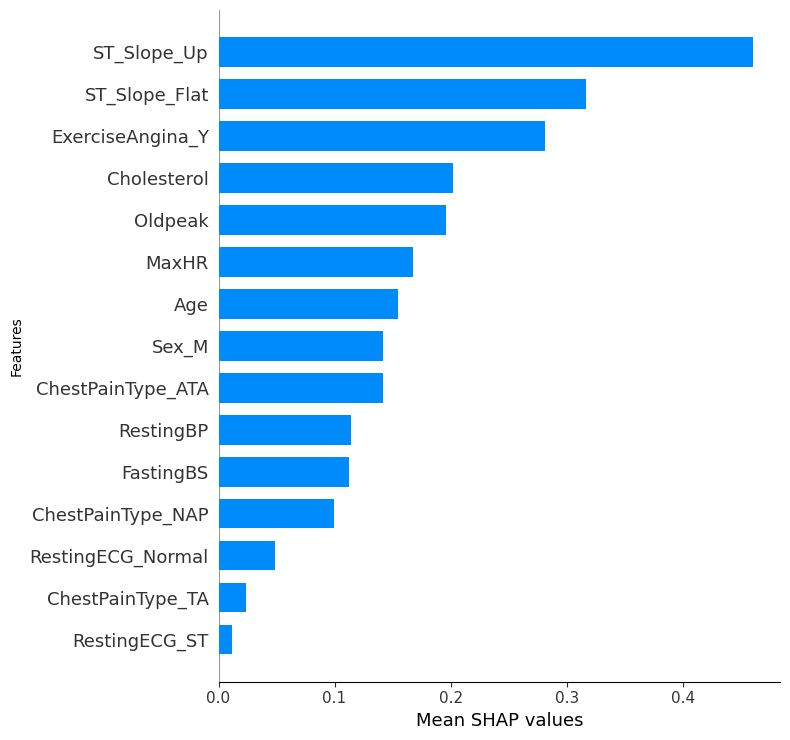

In [ ]:
# 3) Explain + plot
explainer = shap.TreeExplainer(est)
shap_values = explainer.shap_values(sample_X)

# Global importance
shap.summary_plot(shap_values, sample_X, plot_type="bar", show=False) #features are ranked from most to least imp.
plt.xlabel("Mean SHAP values")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

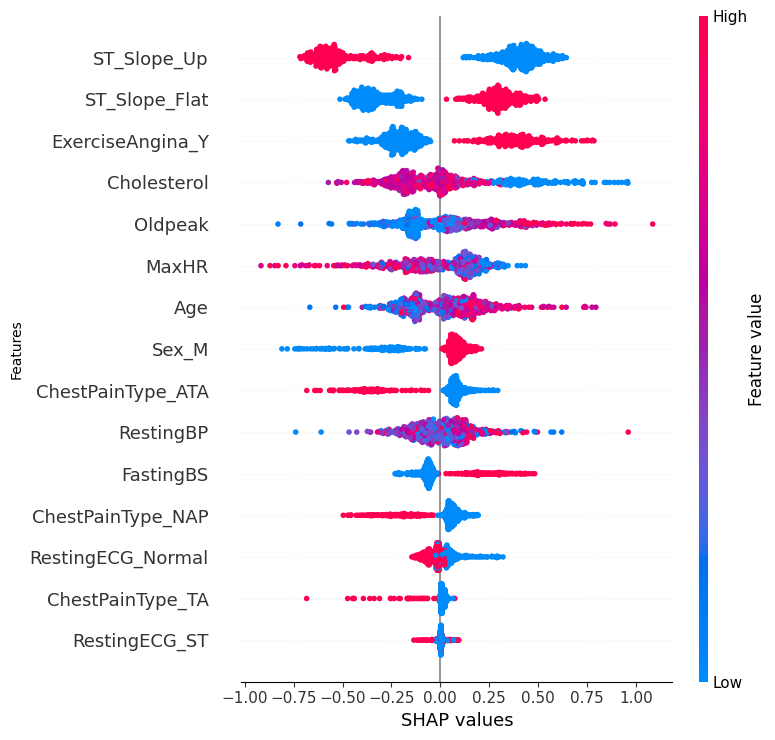

In [ ]:
 #detailed beeswarm

shap.summary_plot(shap_values, sample_X, show=False)
plt.xlabel("SHAP values")
plt.ylabel("Features")
plt.tight_layout(); plt.show()


FLAML after SHAP


In [ ]:
#To get top 10 features
top = np.argsort(automl.model.model.feature_importances_)[::-1][:10] sorts from 10-1
Xtr, Xte = X_train.iloc[:, top], X_test.iloc[:, top]  #df with onlt top 10 features

# train again
auto2 = AutoML()
auto2.fit(Xtr, y_train, task="classification", metric="accuracy",
          estimator_list=["xgboost"], time_budget=300, eval_method="cv", n_splits=6)

# accuracy
print("Accuracy:", accuracy_score(y_test, auto2.predict(Xte)))


[flaml.automl.logger: 08-18 15:43:30] {1752} INFO - task = classification
[flaml.automl.logger: 08-18 15:43:30] {1763} INFO - Evaluation method: cv
[flaml.automl.logger: 08-18 15:43:30] {1862} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 08-18 15:43:30] {1979} INFO - List of ML learners in AutoML Run: ['xgboost']
[flaml.automl.logger: 08-18 15:43:30] {2282} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 08-18 15:43:30] {2417} INFO - Estimated sufficient time budget=1308s. Estimated necessary time budget=1s.
[flaml.automl.logger: 08-18 15:43:30] {2466} INFO -  at 0.2s,	estimator xgboost's best error=0.1662,	best estimator xgboost's best error=0.1662
[flaml.automl.logger: 08-18 15:43:30] {2282} INFO - iteration 1, current learner xgboost
[flaml.automl.logger: 08-18 15:43:30] {2466} INFO -  at 0.3s,	estimator xgboost's best error=0.1662,	best estimator xgboost's best error=0.1662
[flaml.automl.logger: 08-18 15:43:30] {2282} INFO - iteration 2, curren